In [131]:
event_log = pd.read_sql("SELECT * FROM repair_event_log", conn)
wrong_cases = event_log[event_log['taskID'] == 'InformClientWrongPlace']['caseID'].unique()

C:\Users\Seonghee\AppData\Local\Temp\ipykernel_17572\551016727.py:1: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



In [132]:
event_log_clean = event_log[~event_log['caseID'].isin(wrong_cases)].copy()

In [133]:
case_time_df = (
    event_log_clean
    .groupby("caseID")["timestamp"]
    .agg(
        case_start="min",
        case_end="max"
    )
    .reset_index()
)

case_time_df["case_lead_time_min"] = (
    case_time_df["case_end"] - case_time_df["case_start"]
).dt.total_seconds() / 60

case_time_df["case_lead_time_hr"] = (
    case_time_df["case_end"]
    - case_time_df["case_start"]
).dt.total_seconds()/3600

In [134]:
case_time_df

,caseID,case_start,case_end,case_lead_time_min,case_lead_time_hr
0,1,1970-01-02 08:08:00,1970-01-17 15:44:00,22056.0,367.600000
1,2,1970-01-08 05:17:00,1970-01-12 15:14:00,6357.0,105.950000
2,3,1970-01-03 01:03:00,1970-01-07 07:04:00,6121.0,102.016667
3,4,1970-01-03 08:23:00,1970-01-04 23:35:00,2352.0,39.200000
4,5,1970-01-07 20:41:00,1970-01-10 06:05:00,3444.0,57.400000
...,...,...,...,...,...
922,996,1970-01-01 18:08:00,1970-01-02 17:15:00,1387.0,23.116667
923,997,1970-01-06 20:58:00,1970-01-15 04:14:00,11956.0,199.266667
924,998,1970-01-07 01:37:00,1970-01-19 13:55:00,18018.0,300.300000
925,999,1970-01-07 04:43:00,1970-01-07 16:25:00,702.0,11.700000


In [135]:
flow_df = event_log_clean[["caseID", "taskID", "eventtype", "timestamp"]].copy()
flow_df = flow_df.sort_values(["caseID", "timestamp"]).reset_index(drop=True)

flow_df["next_taskID"] = flow_df.groupby("caseID")["taskID"].shift(-1)
flow_df["next_eventtype"] = flow_df.groupby("caseID")["eventtype"].shift(-1)
flow_df["next_timestamp"] = flow_df.groupby("caseID")["timestamp"].shift(-1)

is_transition = (
    (flow_df["eventtype"] == "complete")
    & (flow_df["taskID"] != flow_df["next_taskID"])
)

flow_df["event_gap_min"] = np.where(
    is_transition,
    (flow_df["next_timestamp"] - flow_df["timestamp"]).dt.total_seconds() / 60,
    np.nan
)
flow_df["event_gap_min"] = flow_df["event_gap_min"].clip(lower=0)
flow_df["event_gap_hr"] = flow_df["event_gap_min"] / 60

sample_case = flow_df["caseID"].iloc[0]
flow_df[flow_df["caseID"] == sample_case][
    ["taskID", "eventtype", "timestamp", "next_taskID", "next_timestamp", "next_eventtype", "event_gap_hr"]
]

,taskID,eventtype,timestamp,next_taskID,next_timestamp,next_eventtype,event_gap_hr
0,FirstContact,complete,1970-01-02 08:08:00,MakeTicket,1970-01-02 08:08:00,start,0.000000
1,MakeTicket,start,1970-01-02 08:08:00,MakeTicket,1970-01-02 08:11:00,complete,NaN
2,MakeTicket,complete,1970-01-02 08:11:00,ArrangeSurvey,1970-01-02 08:11:00,start,0.000000
3,ArrangeSurvey,start,1970-01-02 08:11:00,ArrangeSurvey,1970-01-02 08:16:00,complete,NaN
4,ArrangeSurvey,complete,1970-01-02 08:16:00,InformClientSurvey,1970-01-02 08:16:00,complete,0.000000
5,InformClientSurvey,complete,1970-01-02 08:16:00,Survey,1970-01-11 21:33:00,start,229.283333
6,Survey,start,1970-01-11 21:33:00,Survey,1970-01-11 21:56:00,complete,NaN
7,Survey,complete,1970-01-11 21:56:00,InternRepair,1970-01-17 04:36:00,start,126.666667
8,InternRepair,start,1970-01-17 04:36:00,InternRepair,1970-01-17 08:12:00,complete,NaN
9,InternRepair,complete,1970-01-17 08:12:00,RepairReady,1970-01-17 08:12:00,complete,0.000000


In [136]:
true_waiting_df = (
    flow_df[flow_df["event_gap_min"].notna()]
    .groupby("caseID", as_index=False)
    .agg(
        true_waiting_time_min=("event_gap_min", "sum"),
        true_waiting_time_hr=("event_gap_hr", "sum")
    )
)
true_waiting_df

,caseID,true_waiting_time_min,true_waiting_time_hr
0,1,21809.0,363.483333
1,2,6071.0,101.183333
2,3,5874.0,97.900000
3,4,2184.0,36.400000
4,5,3278.0,54.633333
...,...,...,...
922,996,1130.0,18.833333
923,997,11652.0,194.200000
924,998,17758.0,295.966667
925,999,242.0,4.033333


In [137]:
repair_compare_df["caseID"] = repair_compare_df["caseID"].astype(int)
case_time_df["caseID"] = case_time_df["caseID"].astype(int)
true_waiting_df["caseID"] = true_waiting_df["caseID"].astype(int)

In [138]:
analysis_df = (
    repair_compare_df
    .merge(
        case_time_df,
        on="caseID",
        how="left"
    )
    .merge(
        true_waiting_df,
        on="caseID",
        how="left"
    )
)

In [139]:
analysis_df["actual_repair_time_hr"] = (
    analysis_df["actual_repair_time_minutes"]/60
)

analysis_df["waiting_time_hr"] = (
    analysis_df["case_lead_time_hr"]
    - analysis_df["actual_repair_time_hr"]
) # 케이스별 전체 리드타임 - 수리 시간만 제외한 리드타임
analysis_df["is_external_case"] = analysis_df["repair_sequence"].fillna("").str.contains("ExternRepair")

In [140]:
ratio_pooled = analysis_df["true_waiting_time_hr"].sum() / analysis_df["case_lead_time_hr"].sum()
print(f"{ratio_pooled*100:.1f}%")

92.8%


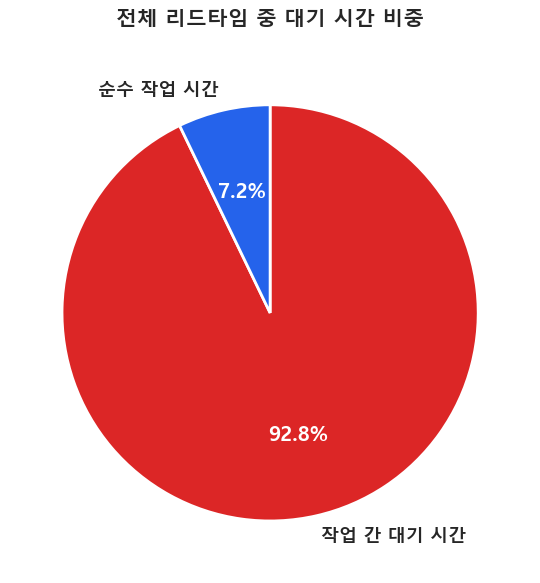

In [141]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

WAITING_PCT = ratio_pooled*100
WORK_PCT = 100 - WAITING_PCT

labels = ["작업 간 대기 시간", "순수 작업 시간"]
values = [WAITING_PCT, WORK_PCT]
colors = ["#DC2626", "#2563EB"]  # 대기(빨강) / 작업(파랑)

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    values,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    textprops={"fontsize": 13, "fontweight": "bold"},
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
for at in autotexts:
    at.set_color("white")
    at.set_fontsize(15)

ax.set_title("전체 리드타임 중 대기 시간 비중", fontsize=15, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("waiting_time_pie.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

In [142]:
add_df = (
    analysis_df[
        ["caseID"
         , "EstimatedRepairTime"
         , "RepairType"
         , "RepairInternally"
         , "RepairCode"
         , "first_repair_start"
         , "last_repair_complete"
         , "actual_repair_time_minutes"
         , "actual_repair_time_hr"
         , "repair_time_diff"
         , "repair_group"
         , "repair_sequence"
         , "case_start"
         , "case_end"
         , "case_lead_time_min_x"
         , "case_lead_time_hr"
         , "true_waiting_time_min"
         , "true_waiting_time_hr"
         , "waiting_time_hr"
         , "is_external_case"
        , "repair_count"]
    ]
    .rename(columns = {"case_lead_time_min_x" : "case_lead_time_min"})
).copy()

In [143]:
rng = np.random.default_rng(42)

# 1. 제품 카테고리 생성 (사용자 로직 반영 + 미세 조정)
def assign_integrated_category(seq, rng):
    # IT/소형(저단가), 생활(표준), 대형(방문/고단가), 정밀/의료(고난도)
    categories = ["IT/소형가전", "생활가전", "대형가전", "정밀/의료기기"]
    probs = np.array([0.30, 0.30, 0.25, 0.15], dtype=float)
    seq = "" if pd.isna(seq) else str(seq)

    # 비즈니스 로직: ExternRepair(외주)는 대형/정밀기기에 집중
    if "ExternRepair" in seq:
        probs += np.array([-0.10, -0.10, 0.10, 0.10])
    # ImmediateRepair(즉시수리)는 IT/소형에 집중
    if "ImmediateRepair" in seq:
        probs += np.array([0.15, 0.05, -0.10, -0.10])
        
    probs = np.clip(probs, 0.05, None)
    probs /= probs.sum()
    return rng.choice(categories, p=probs)

add_df["product_category"] = add_df["repair_sequence"].apply(lambda x: assign_integrated_category(x, rng))

In [144]:
# 2. 보증 상태(Warranty) 생성
# 로직 : 고단가 제품군(정밀, 대형)일수록 보증 내 수리 비중이 높다는 로직 반영
def assign_warranty(cat):
    p_in = {"대형가전" : 0.75, "정밀/의료기기" : 0.70, "생활가전" : 0.50, "IT/소형가전" : 0.40}
    prob = p_in.get(cat, 0.5)
    return rng.choice(["In-Warranty", "Out-of-Warranty"], p = [prob, 1- prob])

add_df["warranty"] = add_df["product_category"].apply(assign_warranty)

In [145]:
# 3. 서비스 우선순위(Priority) 생성
# 보증 내 수리이거나 리드타임이 긴 제품군은 high 부여 확률 증가
def assign_priority(row):
    p = [0.6, 0.3, 0.1] # 기본확률 (Low, Medium, High)
    if row["warranty"] == "In-Warranty": p = [0.4, 0.4, 0.2]
    if row["product_category"] in ["대형가전", "정밀/의료기기"]: p = [0.3, 0.4, 0.3]
    return rng.choice(["Low", "Medium", "High"], p = p)

add_df["priority"] = add_df.apply(assign_priority, axis = 1)

In [146]:
# 4. 제품 가격(product price)
# 카테고리별로 가격 범위 설정
def generate_product_price(cat, rng):
    price_map = {
        "IT/소형가전" : (50000, 300000), # 5만 ~ 30만
        "생활가전" : (300000, 1500000),
        "대형가전" : (1500000, 5000000),
        "정밀/의료기기" : (5000000, 20000000)
    }
    low, high = price_map.get(cat, (100000, 1000000))
    return int(rng.uniform(low, high))

add_df["product_price"] = add_df["product_category"].apply(lambda x: generate_product_price(x, rng))

In [147]:
# 5. 고장 심각도(failure_severity)
# 복합수리(multi)이거나 특정 카테고리일 때 high 확률 증가
def assign_severity(row, rng):
    p = [0.5, 0.3, 0.2] # low, medium, high 기본값

    if row['repair_group'] == 'MultipleRepair': p = [0.2, 0.3, 0.5]
    if row["product_category"] == "정밀/의료기기": p = [0.3, 0.3, 0.4]
    return rng.choice(["low", "medium", "high"], p = p)

add_df["failure_severity"] = add_df.apply(lambda x: assign_severity(x, rng), axis = 1)

In [148]:
# 수리비용(cost) 생성 - 수익성 확인
# 복합수리(multi) 가중치 + 카테고리별 부품 단가 반영
def calculate_cost(row, rng):
    # 1. 고정 베이스 비용
    base_cost = 30000

    # 2. 제품 가격 영향(카테고리에 따라 비율 차등화)
    # 대형/정밀기기는 고가 제품이 많으므로 수리비 비율을 현실적으로 조정
    price_rate_map = {
        "IT/소형가전": rng.uniform(0.10, 0.15), # 저가형은 수리비 비중이 높음
        "생활가전" : rng.uniform(0.07, 0.12),
        "대형가전" : rng.uniform(0.05, 0.10),
        "정밀/의료기기" : rng.uniform(0.04, 0.08)
    }
    price_rate = price_rate_map.get(row["product_category"], 0.08)
    price_cost = row["product_price"] * price_rate

    # 3. 수리 횟수 영향
    count_cost = row["repair_count"] * rng.uniform(20000, 40000)

    # 4. 고장 심각도 영향
    severity_map = {
        "low" : rng.uniform(10000, 30000),
        "medium" : rng.uniform(30000, 60000),
        "high" : rng.uniform(60000, 120000)
    }
    severity_cost = severity_map.get(row["failure_severity"], 30000)

    # 5. Extern Repair 비용(카테고리별 가중치 추가)
    # 대형/정밀기기 외주는 출장비나 정밀 점검비가 더 붙는다고 가정
    extern_cost = 0
    if "ExternRepair" in str(row["repair_sequence"]):
        extern_base = 100000 if row["product_category"] in ["대형가전", "정밀/의료기기"] else 60000
        extern_cost = rng.uniform(extern_base, extern_base + 50000)

    # 6. 노이즈 및 최종 합산
    noise = rng.uniform(-20000, 20000)
    total_cost = base_cost + price_cost + count_cost + severity_cost + extern_cost + noise

    return int(max(15000, total_cost))

add_df["repair_cost"] = add_df.apply(lambda x: calculate_cost(x, rng), axis = 1)

In [149]:
# SLA 상태 정의 - 10,000분 기준
add_df["sla_status"] = add_df["case_lead_time_min"].apply(
    lambda x: "Fail" if x > 10000 else "Success"
)

### 가설 1. 재수리 발생은 사전 일정 준수 실패의 원인인가?

In [150]:
# 실제 수리 시간이 예상보다 짧으면 'Sucess', 길면 "Fail"
add_df["schedule_compliance"] = add_df["repair_time_diff"].apply(
    lambda x: "Fail" if x > 0 else "Success"
)

In [151]:
ct_h1 = pd.crosstab(add_df["repair_count"] >= 2, add_df["schedule_compliance"])
ct_h1

schedule_compliance,Fail,Success
repair_count,,
False,283,517
True,127,0


In [152]:
ct_ratio = ct_h1.div(ct_h1.sum(axis = 1), axis = 0) * 100 # 비율 변환
ct_ratio

schedule_compliance,Fail,Success
repair_count,,
False,35.375,64.625
True,100.000,0.000


<Figure size 1000x600 with 0 Axes>

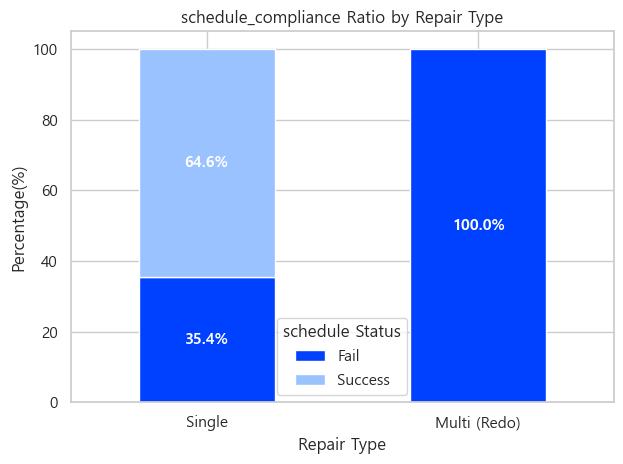

In [153]:
plt.figure(figsize=(10, 6))
ax = ct_ratio.plot(kind="bar", stacked=True, color = ["#0040FF", "#99C2FF"])

for container in ax.containers:
    labels = [f"{v.get_height():.1f}%" if v.get_height() > 0 else "" for v in container]
    ax.bar_label(container, labels=labels, label_type="center", color="white", weight="bold", fontsize=11)

plt.title("schedule_compliance Ratio by Repair Type")
plt.xlabel("Repair Type")
plt.ylabel("Percentage(%)")
ax.set_xticklabels(["Single", "Multi (Redo)"], rotation=0)
plt.legend(title="schedule Status", labels=["Fail", "Success"])

plt.tight_layout()
plt.show()

In [154]:
chi2_h1, p_h1, _, _ = chi2_contingency(ct_h1)
print("H1 p-value: ", p_h1)

H1 p-value:  1.0965150228327562e-41


### 가설 2. 비용 · 다중 수리 여부에 따라 리드타임이 달라지는가?”

In [155]:
# 실제 수리 시간, 과업 간 대기 시간
bottleneck_metrics = ["actual_repair_time_minutes", "true_waiting_time_min"]

# 카테고리별 평균값 계산
data = add_df.groupby("product_category")[bottleneck_metrics].mean()
data.columns = ["평균 실제 수리 시간(분)", "평균 과업 간 대기 시간(분)"]
data

,평균 실제 수리 시간(분),평균 과업 간 대기 시간(분)
product_category,,
IT/소형가전,254.780120,5655.792169
대형가전,350.607330,6438.528796
생활가전,264.569492,5747.332203
정밀/의료기기,368.394495,6089.853211


In [156]:
sns.set_theme(style = "white")

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams["font.family"] = "Malgun Gothic"

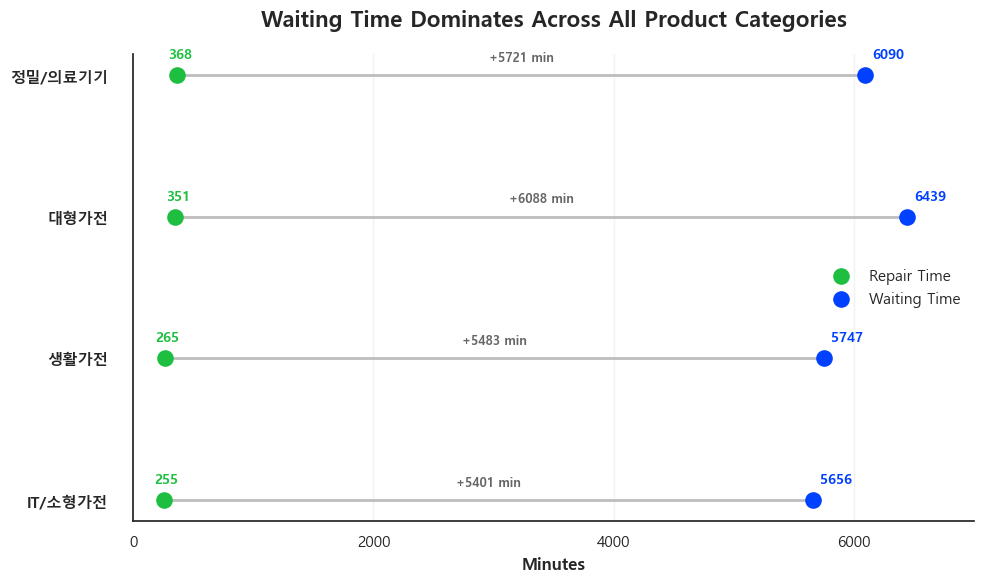

In [157]:
fig, ax = plt.subplots(figsize=(10, 6))

plot_df = data.sort_values("평균 실제 수리 시간(분)").copy()

for i in range(len(plot_df)):
    ax.plot(
        [plot_df["평균 실제 수리 시간(분)"].iloc[i],
         plot_df["평균 과업 간 대기 시간(분)"].iloc[i]],
        [i, i],
        color="#BDBDBD",
        linewidth=2,
        zorder=1
    )


ax.scatter(
    plot_df["평균 실제 수리 시간(분)"],
    range(len(plot_df)),
    color="#1EBE41",
    s=120,
    label="Repair Time",
    zorder=3
)

ax.scatter(
    plot_df["평균 과업 간 대기 시간(분)"],
    range(len(plot_df)),
    color="#0040FF",
    s=120,
    label="Waiting Time",
    zorder=3
)

for i in range(len(plot_df)):
    gap = (
    plot_df["평균 과업 간 대기 시간(분)"].iloc[i]
    - plot_df["평균 실제 수리 시간(분)"].iloc[i]
    )

    mid = (
        plot_df["평균 실제 수리 시간(분)"].iloc[i]
        + plot_df["평균 과업 간 대기 시간(분)"].iloc[i]
    ) / 2

    ax.text(
        mid,
        i + 0.08,
        f"+{gap:.0f} min",
        ha="center",
        va="bottom",
        fontsize=9,
        color="#666666",
        fontweight="bold"
    )

    ax.text(
        plot_df["평균 실제 수리 시간(분)"].iloc[i] - 80,
        i + 0.12,
        f'{plot_df["평균 실제 수리 시간(분)"].iloc[i]:.0f}',
        color="#1EBE41",
        fontsize=10,
        fontweight="bold"
    )

    ax.text(
        plot_df["평균 과업 간 대기 시간(분)"].iloc[i] + 60,
        i + 0.12,
        f'{plot_df["평균 과업 간 대기 시간(분)"].iloc[i]:.0f}',
        color="#0040FF",
        fontsize=10,
        fontweight="bold"
    )

# 축 설정
ax.set_xlim(0, 7000)

ax.set_xticks([0, 2000, 4000, 6000])

ax.set_xlabel(
    "Average Duration (Minutes)",
    fontsize=12,
    fontweight="bold"
)


ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df.index, fontsize=11, fontweight="bold")

ax.tick_params(axis="y", pad=12)

ax.set_xlabel("Minutes", fontsize=12)
ax.set_ylabel("")

ratio = (
    plot_df["평균 과업 간 대기 시간(분)"].mean()
    / plot_df["평균 실제 수리 시간(분)"].mean()
)

ax.set_title(
    "Waiting Time Dominates Across All Product Categories", # f"Waiting Time is {ratio:.1f}× Longer than Repair Time",
    fontsize=16,
    fontweight="bold",
    pad=20
)

ax.grid(axis="x", alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(frameon=False)

plt.tight_layout()
plt.show()

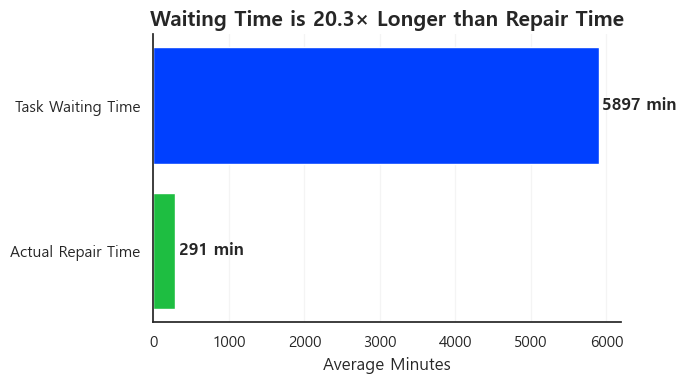

In [158]:
summary = pd.DataFrame({
    "Component": ["Actual Repair Time", "Task Waiting Time"],
    "Minutes": [
        analysis_df["actual_repair_time_minutes"].mean(),
        analysis_df["true_waiting_time_min"].mean()
    ]
})

summary = summary.sort_values("Minutes")

plt.figure(figsize=(7,4))

plt.barh(
    summary["Component"],
    summary["Minutes"],
    color=["#1EBE41", "#0040FF"]
)

for i, v in enumerate(summary["Minutes"]):
    plt.text(v+50, i, f"{v:.0f} min", va="center", fontweight="bold")

ratio = (
    summary["Minutes"].iloc[1] /
    summary["Minutes"].iloc[0]
)

plt.title(
    f"Waiting Time is {ratio:.1f}× Longer than Repair Time",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Average Minutes")

plt.grid(axis="x", alpha=.2)

sns.despine()

plt.tight_layout()
plt.show()

In [159]:
add_df["has_external_repair"] = np.where(
    add_df["repair_sequence"].str.contains("ExternRepair", na = False),
    "External",
    "Internal"
)

add_df["is_multi_repair"] = (add_df["repair_count"] >= 2).astype(int) # 재수리 여부

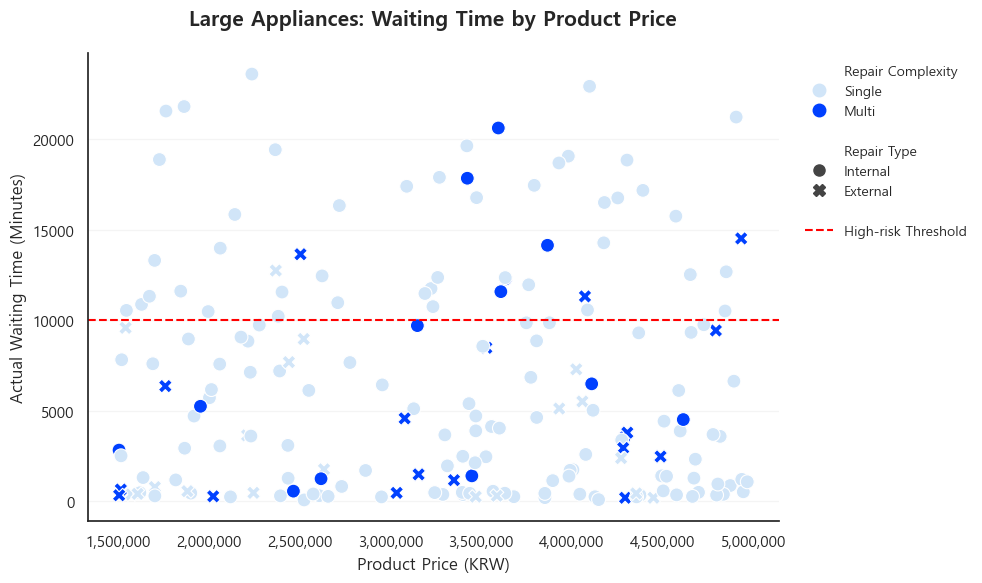

In [160]:
from matplotlib.ticker import StrMethodFormatter

target_df = add_df[add_df["product_category"] == "대형가전"]

fig, ax = plt.subplots(figsize=(10, 6))

palette = {
    0: "#D1E5F8", # single, #1EBE41
    1: "#0040FF" # multi
}

sns.scatterplot(data = target_df, x = "product_price", y = "true_waiting_time_min"
                , hue = "is_multi_repair", style = "has_external_repair", palette = palette, s = 100
               , legend = False, ax = ax)

plt.axhline(10000, color='red', linestyle='--', linewidth = 1.5, label='고위험군 임계점')

legend_elements = [

    # 제목처럼 사용할 빈 항목
    Line2D([], [], linestyle="None", label="Repair Complexity"),

    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor="#D1E5F8",
        markeredgecolor="#D1E5F8",
        markersize=9,
        label="Single"
    ),

    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor="#0040FF",
        markeredgecolor="#0040FF",
        markersize=9,
        label="Multi"
    ),

    Line2D([], [], linestyle="None", label=""),

    Line2D([], [], linestyle="None", label="Repair Type"),

    Line2D(
        [0], [0],
        marker="o",
        color="#444444",
        linestyle="None",
        markersize=8,
        label="Internal"
    ),

    Line2D(
        [0], [0],
        marker="X",
        color="#444444",
        linestyle="None",
        markersize=8,
        label="External"
    ),

    Line2D([], [], linestyle="None", label=""),

    Line2D(
        [0], [0],
        color="red",
        linestyle="--",
        linewidth=1.5,
        label="High-risk Threshold"
    )
]

ax.legend(
    handles=legend_elements,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=10
)

ax.set_title(
    "Large Appliances: Waiting Time by Product Price",
    fontsize=15,
    fontweight="bold",
    pad=20
)

ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

ax.set_xlabel("Product Price (KRW)", fontsize=12)
ax.set_ylabel("Actual Waiting Time (Minutes)", fontsize=12)

ax.grid(axis="y", alpha=0.2)

sns.despine()

plt.tight_layout()
plt.show()

In [161]:
import statsmodels.api as sm

corr, p_value = stats.pearsonr(target_df["product_price"], target_df["case_lead_time_min"])
print(f"피어슨 상관계수(r): {corr:.4f}")
print(f"통계적 유의성(p-value): {p_value:.4f}")

# 선형 회귀 분석(기울기 확인)
X = sm.add_constant(target_df["product_price"])
model = sm.OLS(target_df["case_lead_time_min"], X).fit()
print(model.summary())

피어슨 상관계수(r): -0.0314
통계적 유의성(p-value): 0.6658
                            OLS Regression Results                            
Dep. Variable:     case_lead_time_min   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.1871
Date:                Wed, 09 Sep 2026   Prob (F-statistic):              0.666
Time:                        21:42:16   Log-Likelihood:                -1941.8
No. Observations:                 191   AIC:                             3888.
Df Residuals:                     189   BIC:                             3894.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------


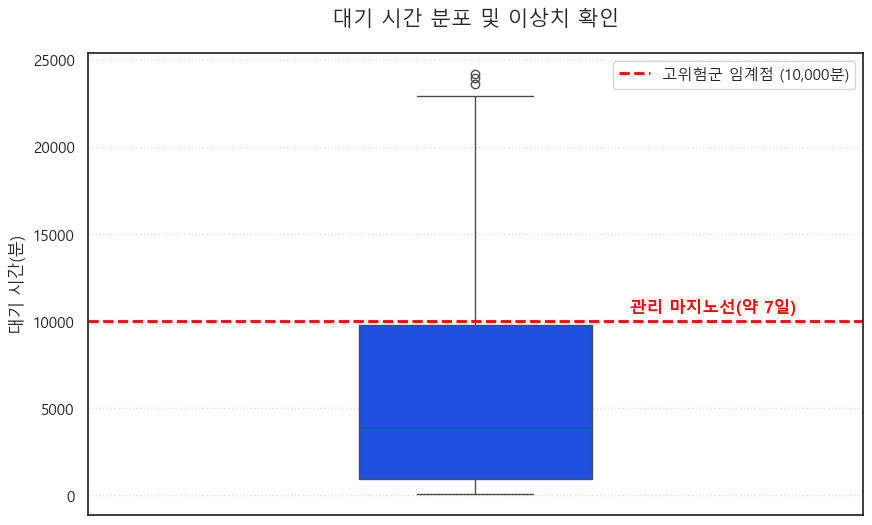

In [162]:
plt.figure(figsize = (10, 6))

sns.boxplot(y = add_df["true_waiting_time_min"], color = "#0040FF", width = 0.3)

# 10,000분 고위험군 임계점 표시
plt.axhline(10000, color = "red", linestyle = "--", linewidth = 2, label = "고위험군 임계점 (10,000분)")

plt.title("대기 시간 분포 및 이상치 확인", fontsize = 15, pad = 20)
plt.ylabel("대기 시간(분)", fontsize = 12)
plt.legend()

plt.text(0.2, 10500, "관리 마지노선(약 7일)", color = "red", fontweight = "bold")

plt.grid(axis = 'y', linestyle = ":", alpha = 0.7)
plt.show()

In [163]:
# 카테고리 별 수리 복잡도 비중 계산
complexity_pct = pd.crosstab(add_df["product_category"], add_df["is_multi_repair"], normalize='index') * 100
complexity_pct

is_multi_repair,0,1
product_category,,
IT/소형가전,87.951807,12.048193
대형가전,83.769634,16.230366
생활가전,86.779661,13.220339
정밀/의료기기,84.403670,15.596330


<Figure size 1000x800 with 0 Axes>

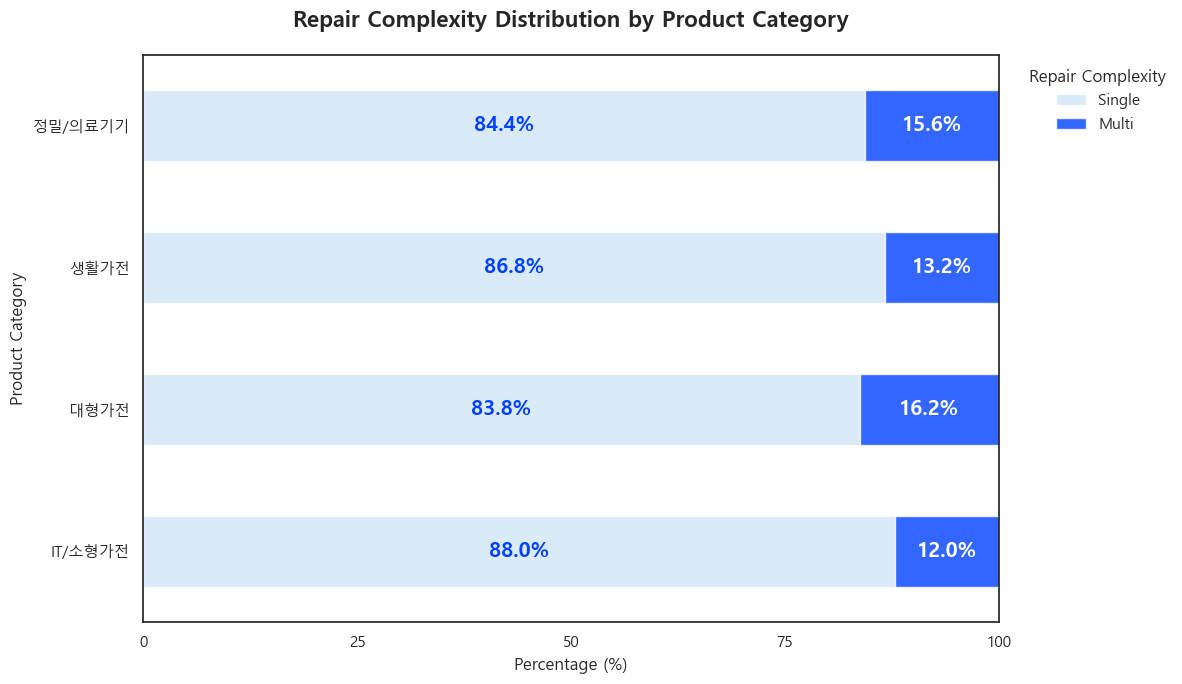

In [164]:
plt.figure(figsize = (10, 8))

ax = complexity_pct.plot(kind = "barh", stacked = True, figsize = (12, 7)
                         , color = ['#D1E5F8', '#0040FF'], alpha = 0.8)

for n, x in enumerate(complexity_pct.index):
    for i, (proportion, y_loc) in enumerate(
        zip(complexity_pct.loc[x], complexity_pct.loc[x].cumsum())
    ):

        txt_color = "#0040FF" if i == 0 else "white"

        plt.text(
            y_loc - proportion / 2,
            n,
            f"{proportion:.1f}%",
            va="center",
            ha="center",
            color=txt_color,
            fontweight="bold",
            fontsize = 15
        )

legend = ax.legend(
    title="Repair Complexity",
    labels=["Single", "Multi"],
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=11,
    title_fontsize=12
)

for h in legend.legend_handles:
    h.set_alpha(0.8)

plt.title(
    "Repair Complexity Distribution by Product Category",
    fontsize=16,
    fontweight="bold",
    pad=20
)

ax.set_xlim(0, 100)
ax.set_xticks([0, 25, 50, 75, 100])

plt.xlabel("Percentage (%)", fontsize=12)
plt.ylabel("Product Category", fontsize=12)
plt.tight_layout()
plt.show()

### 가설 3. “외주 수리는 내부 수리 대비 SLA 실패 가능성이 높은가?”

In [165]:
add_df['repair_type'] = np.where(
    add_df["repair_sequence"].str.contains("ExternRepair", na = False),
    "External",
    "Internal"
)

In [166]:
# 수리 유형별 SLA 준수율
sla_counts = pd.crosstab(add_df["repair_type"], add_df["sla_status"], normalize = "index") * 100

In [167]:
sla_ratio = (sla_counts.div(sla_counts.sum(axis=1), axis=0)* 100)
sla_ratio

sla_status,Fail,Success
repair_type,,
External,14.393939,85.606061
Internal,27.798742,72.201258


<Figure size 1000x600 with 0 Axes>

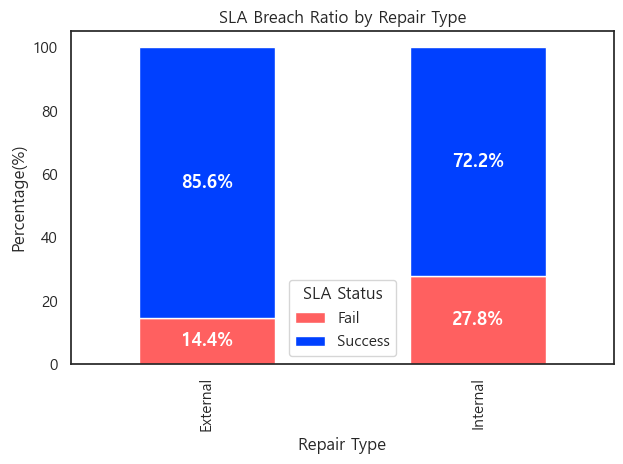

In [168]:
plt.figure(figsize=(10, 6))

colors = ['#FF6060', '#0040FF']

ax = sla_ratio.plot(kind="bar", stacked=True, color=colors)

for container in ax.containers:
    labels = [f"{v.get_height():.1f}%" if v.get_height() > 0 else "" for v in container]
    ax.bar_label(container, labels=labels, label_type="center", color="white", weight="bold", fontsize=13)


plt.title("SLA Breach Ratio by Repair Type")
plt.xlabel("Repair Type")
plt.ylabel("Percentage(%)")
plt.legend(title="SLA Status", labels=["Fail", "Success"])

plt.tight_layout()
plt.show()

In [169]:
chi3, p, dof, ex = chi2_contingency(sla_counts)
print(f"카이제곱 t 값: {chi3:.4f}")
print(f"카이제곱 검정 결과 p-value: {p:.4f}")

카이제곱 t 값: 4.6222
카이제곱 검정 결과 p-value: 0.0316


In [170]:
add_df.groupby("repair_sequence").agg(
    count=("caseID", "count"),
    sla_fail_rate=("sla_status", lambda x: (x == "Fail").mean() * 100)
).sort_values("count", ascending=False)

,count,sla_fail_rate
repair_sequence,,
InternRepair,419,35.083532
ImmediateRepair,322,17.701863
ExternRepair,59,15.254237
ImmediateRepair > ExternRepair,38,5.263158
InternRepair > InternRepair,35,48.571429
InternRepair > ExternRepair,29,27.586207
ImmediateRepair > InternRepair,17,0.000000
ImmediateRepair > InternRepair > ExternRepair,5,0.000000
ImmediateRepair > InternRepair > InternRepair,1,0.000000


In [171]:
add_df["repair_mode"] = "Internal Repair"

# 1. External Repair (최우선) - 외주 포함
external_mask = add_df["repair_sequence"].str.contains(
    "ExternRepair",
    na=False
)

add_df.loc[external_mask, "repair_mode"] = "External Repair"

# 2. Internal Redo
redo_mask = (
    ~external_mask
) & (
    add_df["repair_sequence"].str.count("InternRepair") >= 2
)

add_df.loc[redo_mask, "repair_mode"] = "Internal Redo"

# 3. Immediate Repair
immediate_mask = (
    add_df["repair_sequence"] == "ImmediateRepair"
)

add_df.loc[immediate_mask, "repair_mode"] = "Immediate Repair"

In [172]:
sla_comparison = pd.crosstab(add_df["repair_mode"], add_df["sla_status"], normalize="index") * 100
sla_comparision = sla_comparison.sort_values(by = "Fail")
sla_comparision

sla_status,Fail,Success
repair_mode,,
External Repair,14.393939,85.606061
Immediate Repair,17.701863,82.298137
Internal Repair,33.715596,66.284404
Internal Redo,45.945946,54.054054


<Figure size 1000x600 with 0 Axes>

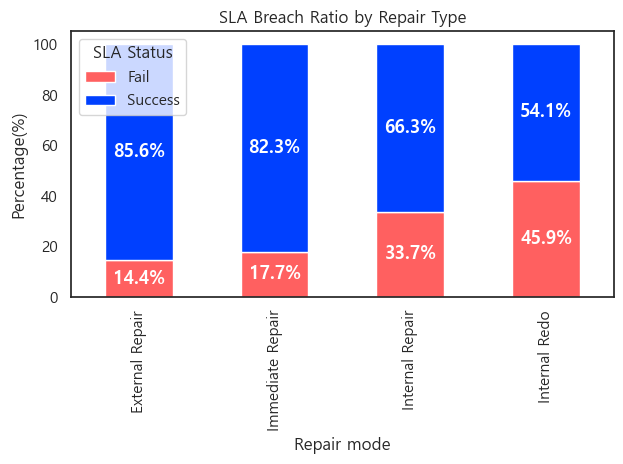

In [173]:
plt.figure(figsize=(10, 6))

colors = ['#FF6060', '#0040FF']

ax = sla_comparision.plot(kind="bar", stacked=True, color=colors)

for container in ax.containers:
    labels = [f"{v.get_height():.1f}%" if v.get_height() > 0 else "" for v in container]
    ax.bar_label(container, labels=labels, label_type="center", color="white", weight="bold", fontsize=13)

plt.title("SLA Breach Ratio by Repair Type")
plt.xlabel("Repair mode")
plt.ylabel("Percentage(%)")
plt.legend(title="SLA Status", labels=["Fail", "Success"])

plt.tight_layout()
plt.show()

In [174]:
# 카테고리 & 보증 여부 별 외부 위탁 비중
ct_warranty = pd.crosstab([add_df["product_category"], add_df["warranty"]], add_df["repair_mode"], normalize = "index") * 100 # repair_type??
ct_warranty

repair_mode                       External Repair  Immediate Repair  \
product_category warranty                                             
IT/소형가전          In-Warranty            11.538462         48.461538   
                 Out-of-Warranty        10.396040         46.534653   
대형가전             In-Warranty            17.164179         22.388060   
                 Out-of-Warranty        22.807018         17.543860   
생활가전             In-Warranty            12.781955         39.097744   
                 Out-of-Warranty         9.259259         40.123457   
정밀/의료기기          In-Warranty            22.619048          7.142857   
                 Out-of-Warranty        36.000000          8.000000   

repair_mode                       Internal Redo  Internal Repair  
product_category warranty                                         
IT/소형가전          In-Warranty           4.615385        35.384615  
                 Out-of-Warranty       1.980198        41.089109  
대형가전             In-Warranty           5.223881        55.223881  
                 Out-of-Warranty       1.754386        57.894737  
생활가전             In-Warranty           3.007519        45.112782  
                 Out-of-Warranty       6.172840        44.444444  
정밀/의료기기          In-Warranty           4.761905        65.476190  
                 Out-of-Warranty       4.000000        52.000000

In [175]:
plot_data = ct_warranty["External Repair"].unstack()
plot_data

warranty,In-Warranty,Out-of-Warranty
product_category,,
IT/소형가전,11.538462,10.396040
대형가전,17.164179,22.807018
생활가전,12.781955,9.259259
정밀/의료기기,22.619048,36.000000


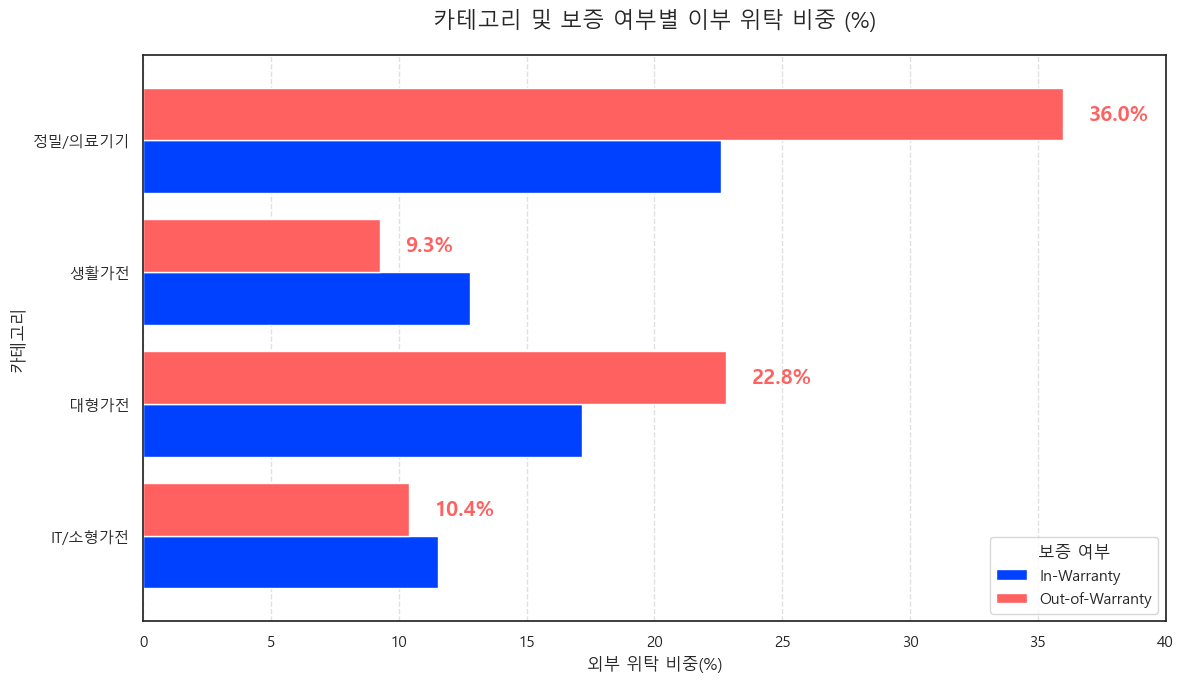

In [176]:
colors = ['#0040FF', '#FF6060']

ax = plot_data.plot(kind = "barh", figsize = (12, 7), color = colors, width = 0.8)

# Out-of-warranty 막대에만 수치 추가
for i, p in enumerate(ax.patches) :
    if i >= len(plot_data):
        width = p.get_width()
        ax.annotate(f"{width:.1f}%", (width + 1, p.get_y() + p.get_height() / 2)
                    , va = "center", fontsize = 15, fontweight = "bold", color = '#FF6060')

plt.title("카테고리 및 보증 여부별 이부 위탁 비중 (%)", fontsize = 16, pad = 20)
plt.xlabel("외부 위탁 비중(%)", fontsize = 12)
plt.ylabel("카테고리", fontsize = 12)
plt.legend(title = "보증 여부", labels = ["In-Warranty", "Out-of-Warranty"], loc = "lower right")

plt.xlim(0, 40)
plt.grid(axis = "x", linestyle = "--", alpha = 0.6)

plt.tight_layout()
plt.show()

### 가설 4. 서비스 우선순위와 고장 심각도가 실제 대기시간 차이로 이어지는가?

In [177]:
sla_ratio = pd.crosstab(add_df["priority"], add_df["sla_status"], normalize = "index") * 100
sla_ratio

sla_status,Fail,Success
priority,,
High,25.988701,74.011299
Low,24.879227,75.120773
Medium,27.083333,72.916667


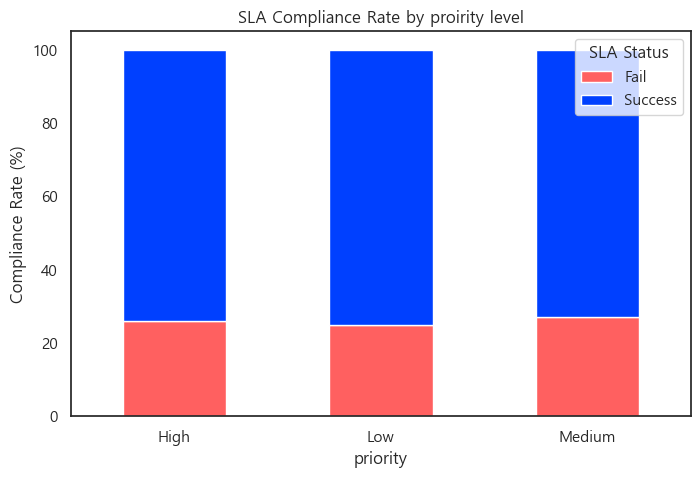

In [178]:
colors = ['#FF6060', '#0040FF']

sla_ratio.plot(kind = "bar", stacked = True, color = colors, figsize = (8, 5))
plt.title("SLA Compliance Rate by proirity level")
plt.legend(title = "SLA Status", loc = "upper right")
plt.xticks(rotation = 0)
plt.xlabel("priority")
plt.ylabel("Compliance Rate (%)")
plt.show()

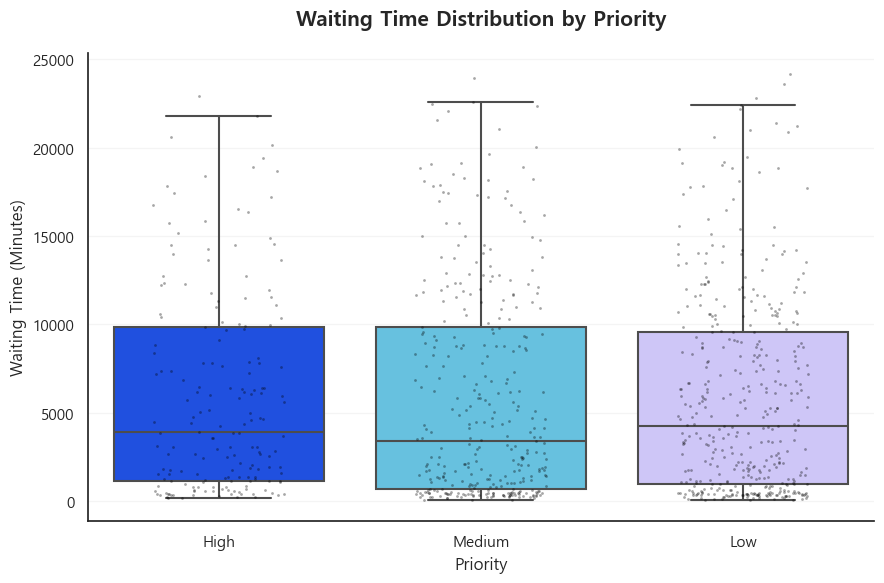

In [179]:
# 서비스 우선순위 vs 평균 실제 대기 시간(수리 시간만 제외)
palette = {
    "High": "#0040FF",
    "Medium": "#53CBF3",
    "Low": "#C9BEFF"
}


plt.figure(figsize=(9,6))

ax = sns.boxplot(
    data=add_df,
    x="priority",
    y="true_waiting_time_min",
    order=["High", "Medium", "Low"],
    hue="priority",
    palette=palette,
    legend=False,
    showfliers=False,
    linewidth=1.5
)

sns.stripplot(
    data=add_df,
    x="priority",
    y="true_waiting_time_min",
    order=["High", "Medium", "Low"],
    color="black",
    alpha=0.35,
    size=2,
    jitter=0.25
)

plt.title(
    "Waiting Time Distribution by Priority",
    fontsize=15,
    fontweight="bold",
    pad=20
)

plt.xlabel("Priority")
plt.ylabel("Waiting Time (Minutes)")

plt.grid(axis="y", alpha=.2)

sns.despine()

plt.tight_layout()
plt.show()

C:\Users\Seonghee\AppData\Local\Temp\ipykernel_17572\2950577503.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




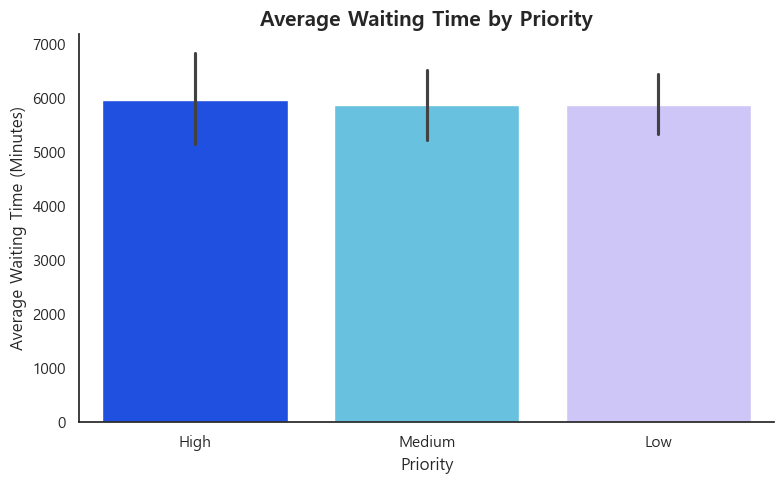

In [180]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=add_df,
    x="priority",
    y="true_waiting_time_min",
    order=["High","Medium","Low"],
    palette=palette,
    errorbar=("ci",95)
)

plt.title(
    "Average Waiting Time by Priority",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Average Waiting Time (Minutes)")
plt.xlabel("Priority")

sns.despine()

plt.tight_layout()
plt.show()

In [181]:
from scipy.stats import kruskal

high = add_df.loc[add_df["priority"] == "High", "true_waiting_time_min"]
medium = add_df.loc[add_df["priority"] == "Medium", "true_waiting_time_min"]
low = add_df.loc[add_df["priority"] == "Low", "true_waiting_time_min"]

stat, p = kruskal(high, medium, low)

print(f"H statistic : {stat:.3f}")
print(f"p-value     : {p:.5f}")

H statistic : 0.814
p-value     : 0.66565


In [182]:
N = len(add_df)
k = 3

epsilon_sq = (stat - k + 1) / (N - k)

print(f"Epsilon² : {epsilon_sq:.4f}")

Epsilon² : -0.0013


In [183]:
if p < 0.05:
    print("✔ Significant difference among priority groups.")
else:
    print("✔ No significant difference among priority groups.")

if epsilon_sq < 0.01:
    print("Effect size : Negligible")
elif epsilon_sq < 0.08:
    print("Effect size : Small")
elif epsilon_sq < 0.26:
    print("Effect size : Medium")
else:
    print("Effect size : Large")

# 차이가 없을 뿐 아니라 차이의 규모도 매우 작다

✔ No significant difference among priority groups.
Effect size : Negligible


In [184]:
add_df["priority"].value_counts()

priority
Low       414
Medium    336
High      177
Name: count, dtype: int64

In [185]:
pd.crosstab(
    add_df["priority"],
    add_df["is_multi_repair"],
    normalize="index"
).round(3) * 100

is_multi_repair,0,1
priority,,
High,85.3,14.7
Low,86.2,13.8
Medium,86.9,13.1


In [186]:
# 우선순위 역전 현상 분석(우선순위가 높은게 더 빨리 처리되는가를 비교함)
# 접수 순서(case start) 대비 처리 순서(first repair start) 비교
rank_df = add_df.copy()

rank_df["start_rank"] = rank_df["case_start"].rank()
rank_df["repair_rank"] = rank_df["first_repair_start"].rank()

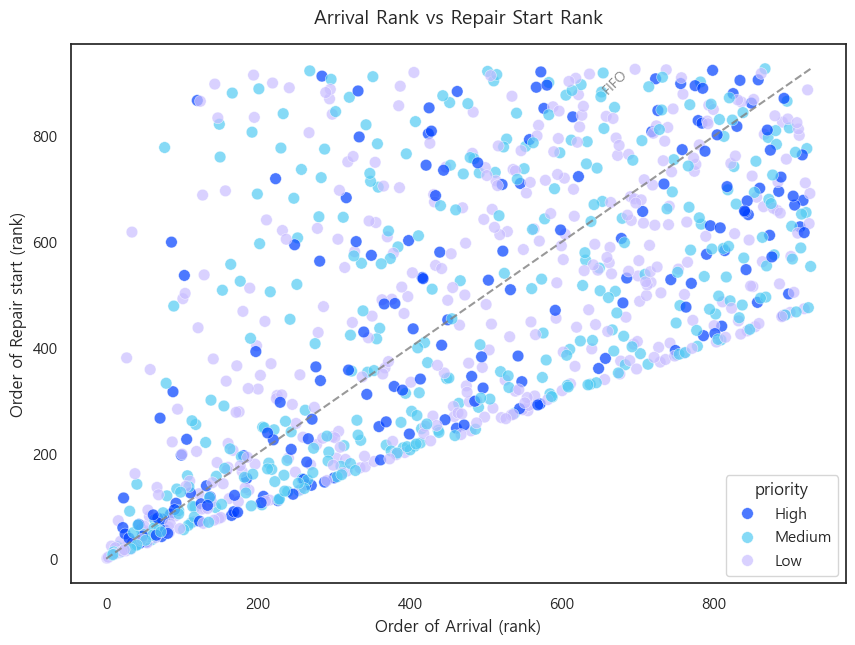

In [187]:
plt.figure(figsize = (10, 7))

palette = {
    "High": "#0040FF",
    "Medium": "#53CBF3",
    "Low": "#C9BEFF"
}


sns.scatterplot(
    data=rank_df,
    x="start_rank",
    y="repair_rank",
    hue="priority",
    hue_order=["High","Medium","Low"],
    palette=palette,
    s=70,
    # edgecolor="black",
    linewidth=0.4,
    alpha=0.7
)

plt.plot(
    [0, rank_df["start_rank"].max()],
    [0, rank_df["start_rank"].max()],
    linestyle="--",
    color="gray",
    linewidth=1.5,
    alpha=0.8
)

plt.text(
    650,
    880,
    "FIFO",
    color="gray",
    fontsize=10,
    rotation=45
)

plt.title("Arrival Rank vs Repair Start Rank", fontsize = 14, pad = 15)
plt.xlabel("Order of Arrival (rank)")
plt.ylabel("Order of Repair start (rank)")
plt.show()

In [188]:
# 고장심각도
severity_analysis = (
    add_df
    .groupby("failure_severity", as_index=False)
    .agg(
        avg_waiting_time=("true_waiting_time_min", "mean"),
        sla_fail_rate=("sla_status", lambda x: (x == "Fail").mean() * 100) # fail의 비율
    )
)
severity_analysis

,failure_severity,avg_waiting_time,sla_fail_rate
0,high,6218.681034,25.000000
1,low,6040.333333,27.380952
2,medium,5407.509091,24.363636


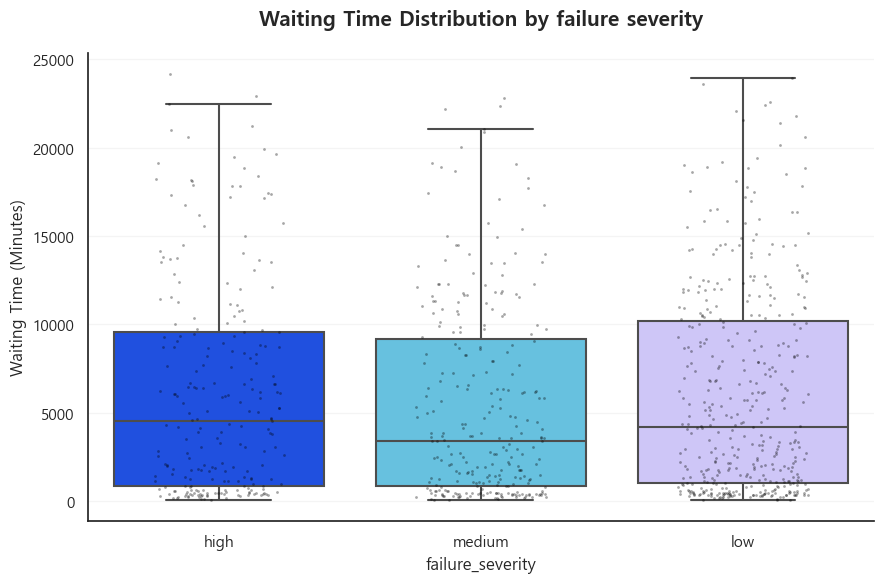

In [189]:
# 수리 심각 vs 평균 실제 대기 시간(수리 시간만 제외)
palette = {
    "high": "#0040FF",
    "medium": "#53CBF3",
    "low": "#C9BEFF"
}


plt.figure(figsize=(9,6))

ax = sns.boxplot(
    data=add_df,
    x="failure_severity",
    y="true_waiting_time_min",
    order=["high", "medium", "low"],
    hue="failure_severity",
    palette=palette,
    legend=False,
    showfliers=False,
    linewidth=1.5
)

sns.stripplot(
    data=add_df,
    x="failure_severity",
    y="true_waiting_time_min",
    order=["high", "medium", "low"],
    color="black",
    alpha=0.35,
    size=2,
    jitter=0.25
)

plt.title(
    "Waiting Time Distribution by failure severity",
    fontsize=15,
    fontweight="bold",
    pad=20
)

plt.xlabel("failure_severity")
plt.ylabel("Waiting Time (Minutes)")

plt.grid(axis="y", alpha=.2)

sns.despine()

plt.tight_layout()
plt.show()

In [190]:
high = add_df.loc[add_df["failure_severity"] == "high", "true_waiting_time_min"]
medium = add_df.loc[add_df["failure_severity"] == "medium", "true_waiting_time_min"]
low = add_df.loc[add_df["failure_severity"] == "low", "true_waiting_time_min"]

stat, p = kruskal(high, medium, low)

print(f"H statistic : {stat:.3f}")
print(f"p-value     : {p:.5f}")

H statistic : 2.746
p-value     : 0.25339


In [191]:
N = len(add_df)
k = 3

epsilon_sq = (stat - k + 1) / (N - k)

print(f"Epsilon² : {epsilon_sq:.4f}")

Epsilon² : 0.0008


In [192]:
if p < 0.05:
    print("✔ Significant difference among priority groups.")
else:
    print("✔ No significant difference among priority groups.")

if epsilon_sq < 0.01:
    print("Effect size : Negligible")
elif epsilon_sq < 0.08:
    print("Effect size : Small")
elif epsilon_sq < 0.26:
    print("Effect size : Medium")
else:
    print("Effect size : Large")


✔ No significant difference among priority groups.
Effect size : Negligible


### 수리비용 특성 분석

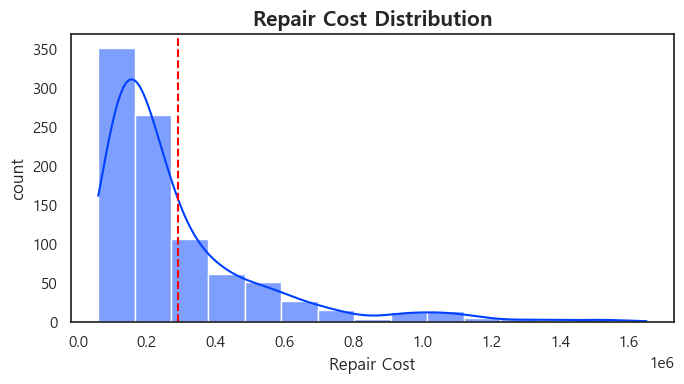

In [193]:
# 수리비 분포
plt.figure(figsize = (7, 4))
sns.histplot(add_df["repair_cost"], bins = 15, kde = True, color = "#0040FF", edgecolor = "white")
mean_cycle = add_df["repair_cost"].mean()

plt.axvline(mean_cycle, color = "red", linestyle = "--", label = "Average")

plt.title("Repair Cost Distribution", fontsize = 15, weight = "bold")
plt.xlabel("Repair Cost")
plt.ylabel("count")

plt.tight_layout()
plt.show()

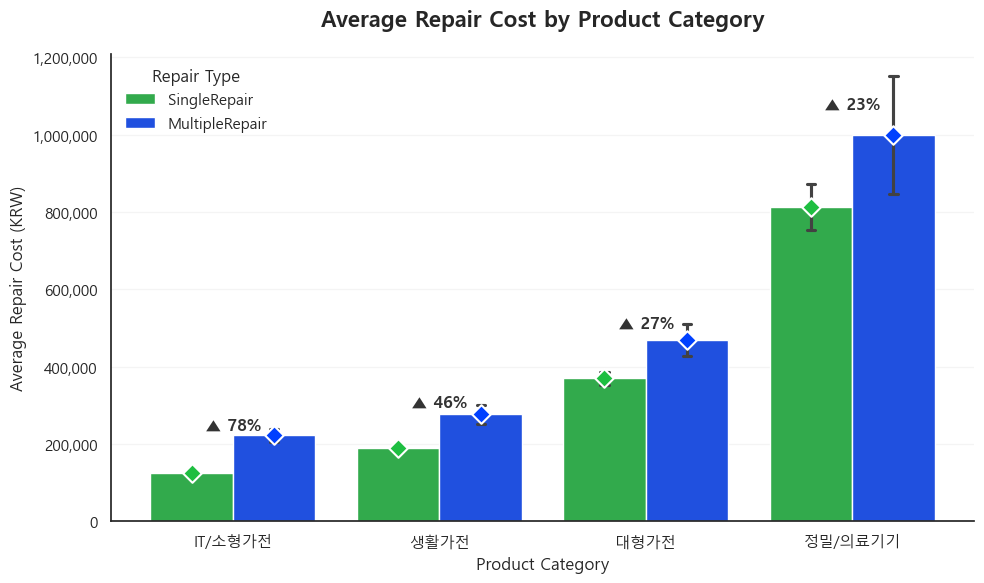

In [194]:
# 고비용/저비용 케이스의 Lead Time 비교
palette = {
    "SingleRepair": "#1EBE41",
    "MultipleRepair": "#0040FF",
}

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=add_df,
    x="product_category",
    y="repair_cost",
    hue="repair_group",
    order=["IT/소형가전", "생활가전", "대형가전", "정밀/의료기기"],
    palette=palette,
    errorbar=("ci", 95),      # 95% CI
    capsize=0.08
)

# y축 천 단위
ax.yaxis.set_major_formatter(
    mtick.StrMethodFormatter('{x:,.0f}')
)

# 평균값 계산
mean_df = (
    add_df
    .groupby(["product_category", "repair_group"], as_index=False)
    .agg(mean_cost=("repair_cost", "mean"))
)

order = ["IT/소형가전", "생활가전", "대형가전", "정밀/의료기기"]

offset = {
    "SingleRepair": -0.20,
    "MultipleRepair": 0.20
}

# 평균 마커 추가(다이아몬드)
for _, row in mean_df.iterrows():

    x = order.index(row["product_category"]) + offset[row["repair_group"]]

    ax.scatter(
        x,
        row["mean_cost"],
        marker="D",
        s=90,
        color=palette[row["repair_group"]],
        edgecolor="white",
        linewidth=1.5,
        zorder=10
    )

# single -> multi 증가율 표시
pivot = (
    mean_df
    .pivot(index="product_category",
           columns="repair_group",
           values="mean_cost")
)

for i, cat in enumerate(order):

    single = pivot.loc[cat, "SingleRepair"]
    multi = pivot.loc[cat, "MultipleRepair"]

    increase = (multi - single) / single * 100

    ax.text(
        i,
        multi + multi*0.07,
        f"▲ {increase:.0f}%",
        ha="center",
        fontsize=12,
        fontweight="bold",
        color="#333333"
    )


plt.title(
    "Average Repair Cost by Product Category",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Average Repair Cost (KRW)", fontsize=12)

plt.grid(axis="y", alpha=0.2)

sns.despine()

plt.legend(
    title="Repair Type",
    frameon=False
)

plt.tight_layout()
plt.show()

전체 케이스 수: 927
전체 Repair Cost 합계: 269,860,487원
Top 10% (93건)이 전체 Repair Cost의 31.4% 차지
Top 20% (186건)이 전체 Repair Cost의 48.3% 차지
Bottom 80% (741건)이 전체 Repair Cost의 51.7% 차지


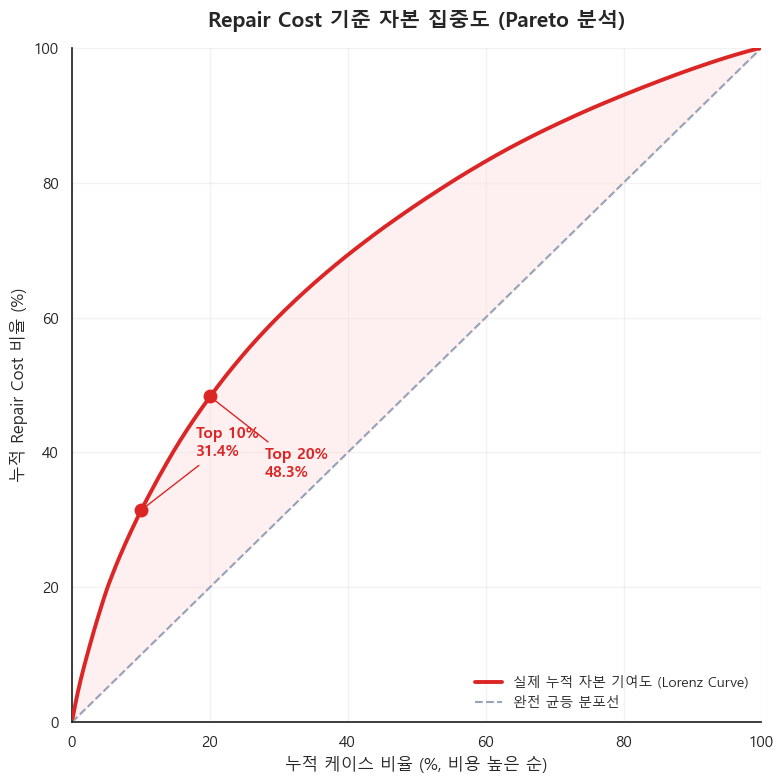

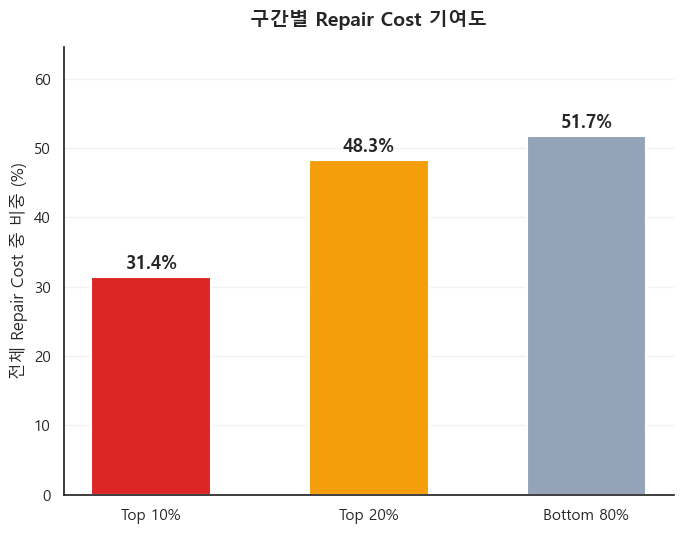

In [195]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = add_df.dropna(subset=["repair_cost"]).copy()

costs = df["repair_cost"].sort_values(ascending=False).reset_index(drop=True)
total_cost = costs.sum()
n = len(costs)

# ============================================================
# 2. 상위 구간별 자본 기여도 계산
# ============================================================
def top_pct_contribution(costs, pct, n):
    k = int(np.ceil(n * pct))
    return costs.iloc[:k].sum() / costs.sum() * 100

top10_share = top_pct_contribution(costs, 0.10, n)
top20_share = top_pct_contribution(costs, 0.20, n)
bottom80_share = 100 - top20_share

print(f"전체 케이스 수: {n}")
print(f"전체 Repair Cost 합계: {total_cost:,.0f}원")
print(f"Top 10% ({int(np.ceil(n*0.10))}건)이 전체 Repair Cost의 {top10_share:.1f}% 차지")
print(f"Top 20% ({int(np.ceil(n*0.20))}건)이 전체 Repair Cost의 {top20_share:.1f}% 차지")
print(f"Bottom 80% ({n - int(np.ceil(n*0.20))}건)이 전체 Repair Cost의 {bottom80_share:.1f}% 차지")

# ============================================================
# 3. Lorenz Curve (누적 기여도 곡선) 계산
# ============================================================
cum_cost_share = costs.cumsum() / total_cost * 100
cum_case_share = np.arange(1, n + 1) / n * 100

# ============================================================
# 4. 시각화 — Lorenz Curve + 주요 구간 강조
# ============================================================
COLOR_LINE = "#DC2626"
COLOR_EQUAL = "#94A3B8"
COLOR_FILL = "#FEE2E2"

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(cum_case_share, cum_cost_share, color=COLOR_LINE, linewidth=2.8,
        label="실제 누적 자본 기여도 (Lorenz Curve)", zorder=3)
ax.plot([0, 100], [0, 100], color=COLOR_EQUAL, linewidth=1.5,
        linestyle="--", label="완전 균등 분포선", zorder=2)
ax.fill_between(cum_case_share, cum_cost_share, cum_case_share,
                 color=COLOR_FILL, alpha=0.5, zorder=1)

# Top10%, Top20% 지점 강조
for pct, share, label_y_offset in [(10, top10_share, 8), (20, top20_share, -12)]:
    ax.plot(pct, share, "o", color=COLOR_LINE, markersize=9, zorder=4)
    ax.annotate(f"Top {pct}%\n{share:.1f}%",
                xy=(pct, share), xytext=(pct + 8, share + label_y_offset),
                fontsize=11, fontweight="bold", color=COLOR_LINE,
                arrowprops=dict(arrowstyle="-", color=COLOR_LINE, lw=1))

ax.set_xlabel("누적 케이스 비율 (%, 비용 높은 순)", fontsize=12)
ax.set_ylabel("누적 Repair Cost 비율 (%)", fontsize=12)
ax.set_title("Repair Cost 기준 자본 집중도 (Pareto 분석)", fontsize=15, fontweight="bold", pad=15)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.legend(loc="lower right", fontsize=10, frameon=False)
ax.grid(alpha=0.25)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("repair_cost_pareto.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

fig2, ax2 = plt.subplots(figsize=(7, 5.5))

bar_labels = ["Top 10%", "Top 20%", "Bottom 80%"]
bar_values = [top10_share, top20_share, bottom80_share]
bar_colors = ["#DC2626", "#F59E0B", "#94A3B8"]

bars = ax2.bar(bar_labels, bar_values, color=bar_colors, width=0.55,
                edgecolor="white", linewidth=1.5)

for bar, val in zip(bars, bar_values):
    ax2.annotate(f"{val:.1f}%", xy=(bar.get_x() + bar.get_width()/2, val),
                 xytext=(0, 6), textcoords="offset points",
                 ha="center", fontsize=13, fontweight="bold")

ax2.set_ylabel("전체 Repair Cost 중 비중 (%)", fontsize=12)
ax2.set_title("구간별 Repair Cost 기여도", fontsize=14, fontweight="bold", pad=15)
ax2.set_ylim(0, max(bar_values) * 1.25)
ax2.grid(axis="y", alpha=0.25)
for spine in ["top", "right"]:
    ax2.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("repair_cost_pareto_bar.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()